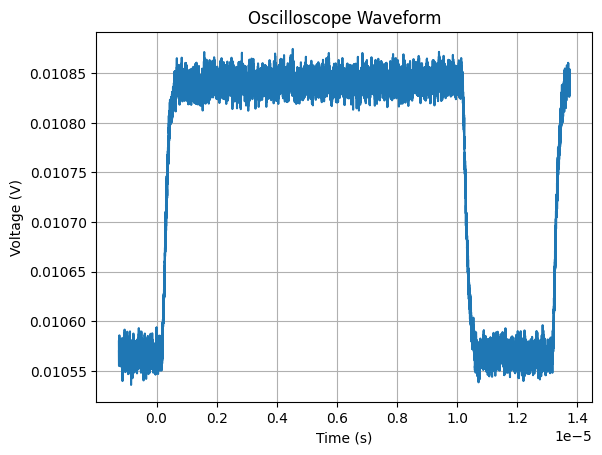

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load CSV (skip header row)
data = np.loadtxt("D:/Students/Nadia/Measurements/dry/rep_0/tau_2uS_2_.csv", delimiter=",", skiprows=1)

time = data[:, 0]
voltage = data[:, 1]

# Plot
plt.figure()
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Waveform")
plt.grid(True)
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load CSV (skip header row)
data = np.loadtxt("2026-05-21_100uM_4/averaged_results/averaged_tau_2uS_2.csv", delimiter=",", skiprows=1)

time = data[:, 0]
voltage = data[:, 1]

# Plot
plt.figure()
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Waveform")
plt.grid(True)
plt.show()


FileNotFoundError: 2026-05-21_100uM_4/averaged_results/averaged_tau_2uS_2.csv not found.

---

In [21]:
import pandas as pd
import glob

num_tau = "tau_1264uS_27"
files = sorted(glob.glob(f"{num_tau}/waveform_*.csv"))

dataframes = []

for f in files:
    df_read = pd.read_csv(f)
    dataframes.append(df_read["Voltage (V)"])

# combine voltages column-wise
combined = pd.concat(dataframes, axis=1)

# compute average voltage
avg_voltage = combined.mean(axis=1)

# use time from first file
time_read = pd.read_csv(files[0])["Time (s)"]

avg_df = pd.DataFrame({
    "Time (s)": time_read,
    "Voltage (V)": avg_voltage 
    # Please add STD.DEV
})


avg_df.to_csv(f"{num_tau}/averaged_waveform.csv", index=False)


In [ ]:
import pandas as pd
import glob

num_tau = 2

files = glob.glob(f"tau_{num_tau}uS/waveform_*.csv")

dataframes = []

for i, f in enumerate(files):
    # if i 
    df_read = pd.read_csv(f)
    dataframes.append(df_read["Voltage (V)"])

# combine voltages column-wise
combined = pd.concat(dataframes, axis=1)

# compute average voltage
avg_voltage = combined.mean(axis=1)

# use time from first file
time_read = pd.read_csv(files[0])["Time (s)"]

avg_df = pd.DataFrame({
    "Time (s)": time_read,
    "Voltage (V)": avg_voltage 
    # Please add STD.DEV
})


avg_df.to_csv(f"tau_{num_tau}uS/averaged_waveform.csv", index=False)

In [7]:
import os

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

# Example usage:
directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)

# def list_files_os(directory_path):
#     files_list = []
#     # Iterate over all entries in the directory
#     for entry_name in os.listdir(directory_path):
#         # Create the full path for each entry
#         full_path = os.path.join(directory_path, entry_name)
#         # Check if the entry is a file
#         if os.path.isfile(full_path):
#             files_list.append(entry_name)
#     return files_list

def num_files(directory_path):
    length = 0
    for entry_name in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry_name)
        if os.path.isfile(full_path):
            length += 1
    return length

files = num_files(folders[0])
print(files)

200


# Averaging Waveforms

In [21]:
import pandas as pd
import numpy as np
import os

# --- FUNCTIONS ---
def list_rep_folders(directory_path):
    """Get all rep_X folders sorted by index."""
    return sorted(
        [name for name in os.listdir(directory_path)
         if os.path.isdir(os.path.join(directory_path, name)) and name.startswith("rep_")],
        key=lambda x: int(x.split("_")[1])
    )

def list_tau_files(folder):
    """Get all tau files in a rep folder, sorted by tau index."""
    return sorted(
        [f for f in os.listdir(folder) if f.startswith("tau_")],
        key=lambda x: int(x.split("_")[2].replace("uS", ""))  # sort by tau value
    )

# --- MAIN ---
input_dir = input("input the directory path: ")
directory_to_scan = input_dir.strip().strip('"')  # remove surrounding quotes if user copy-pastes with them
output_dir = os.path.join(directory_to_scan, "averaged_results")
os.makedirs(output_dir, exist_ok=True)

# rep_folders = list_rep_folders(directory_to_scan)
# print(f"Found rep folders: {rep_folders}")

rep_folders = [os.path.join(directory_to_scan, name) for name in list_rep_folders(directory_to_scan)]
print(f"Found rep folders: {rep_folders}")

# Get tau file list from first rep folder as reference
tau_files_ref = list_tau_files(rep_folders[0])

for tau_file in tau_files_ref:
    dataframe_list = []

    for rep in rep_folders:
        file_path = os.path.join(rep, tau_file)
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found, skipping.")
            continue
        df = pd.read_csv(file_path)
        dataframe_list.append(df["Voltage (V)"])

    if not dataframe_list:
        print(f"No data found for {tau_file}, skipping.")
        continue

    # --- COMBINE, MEAN, STD ---
    combined = pd.concat(dataframe_list, axis=1)
    avg_voltage = combined.mean(axis=1)
    std_voltage = combined.std(axis=1)

    # --- TIME axis from first rep ---
    time = pd.read_csv(os.path.join(rep_folders[0], tau_file))["Time (s)"]

    # --- SAVE ---
    tau_label = tau_file.replace("_.csv", "")  # e.g. "tau_100uS_0"
    avg_df = pd.DataFrame({
        "Time (s)": time,
        "Voltage (V)": avg_voltage,
        "Std (V)": std_voltage
    })
    out_path = os.path.join(output_dir, f"averaged_{tau_label}.csv")
    avg_df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

Found rep folders: ['D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_0', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_1', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_2', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_3', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_4', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_5', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_6', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_7', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_8', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_9', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_10', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_11', 'D:\\Students\\Nadia\\Measurements\\manganese\\2026-05-20_100uM_3\\rep_12', 'D

In [15]:
import os

# works as long as notebook is in the same folder as rep_ folders
notebook_dir = os.path.abspath('')  # Jupyter-safe alternative to __file__
os.chdir(notebook_dir)
directory_to_scan = notebook_dir
print(directory_to_scan)
print([f for f in os.listdir(directory_to_scan) if f.startswith("rep_")])

d:\Students\Nadia\Measurements\manganese
[]


In [4]:
rep_folders

[]

# Plot Data

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


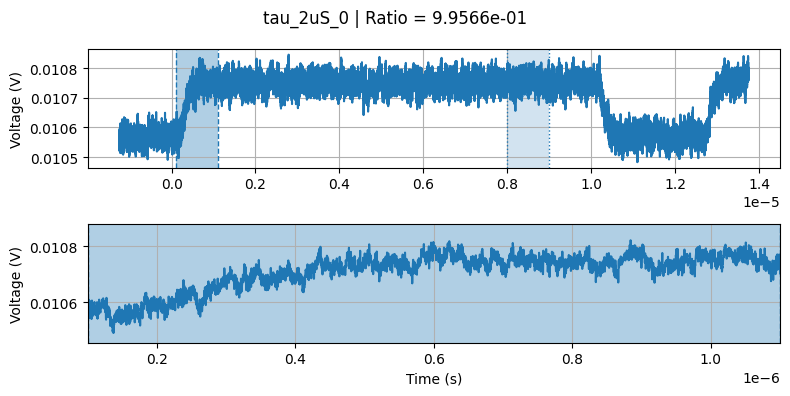

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


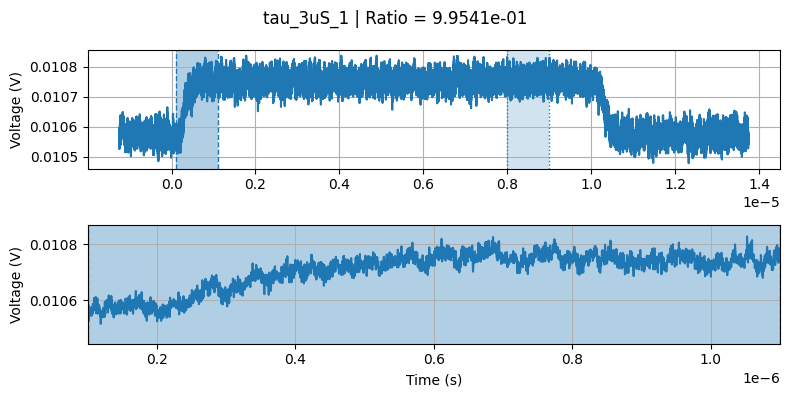

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


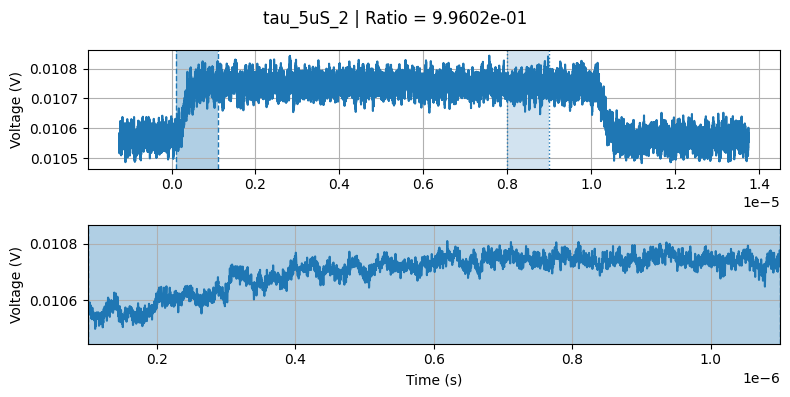

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


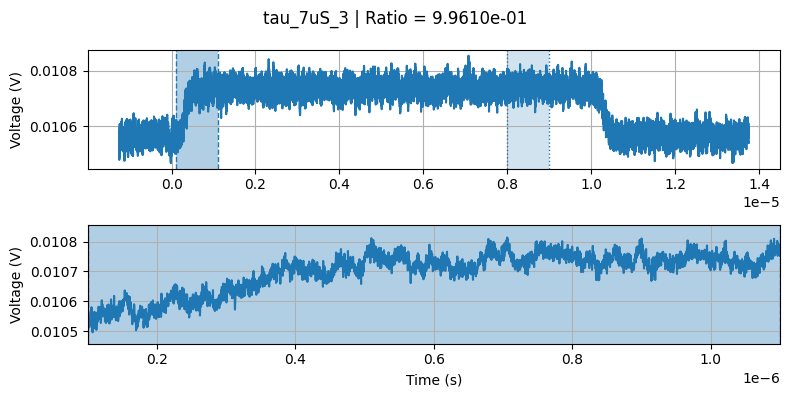

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


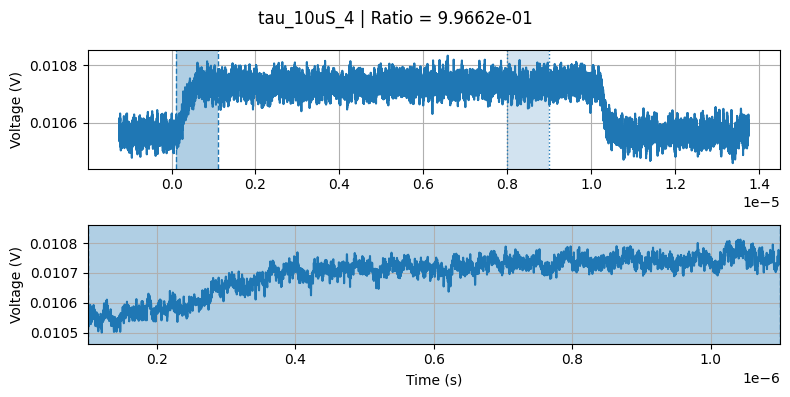

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


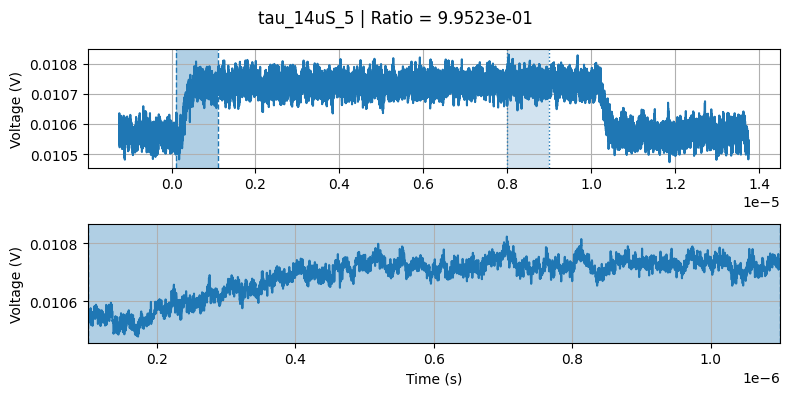

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


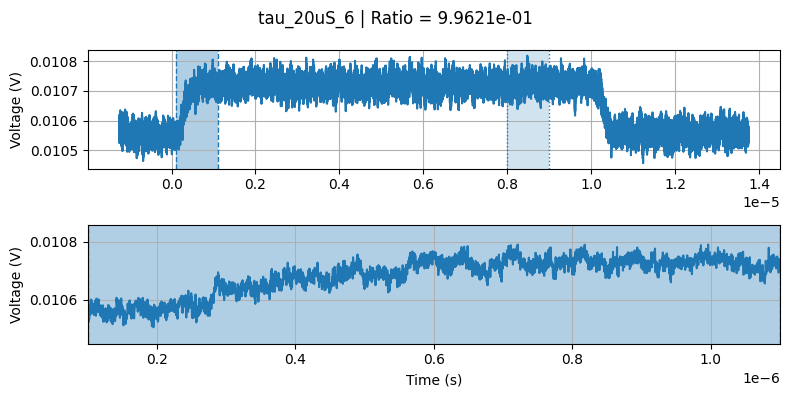

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


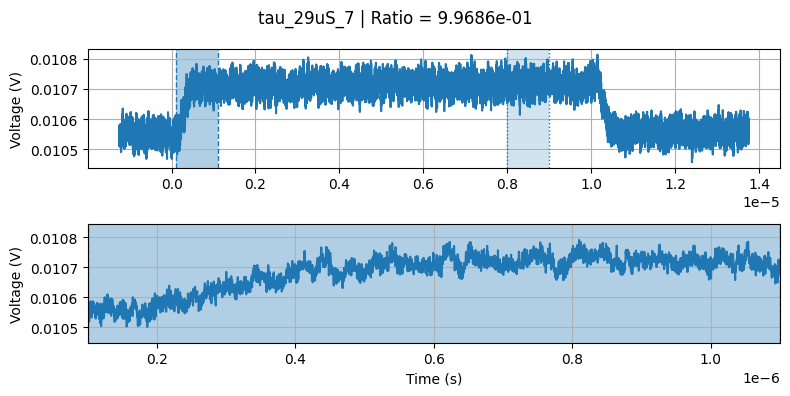

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


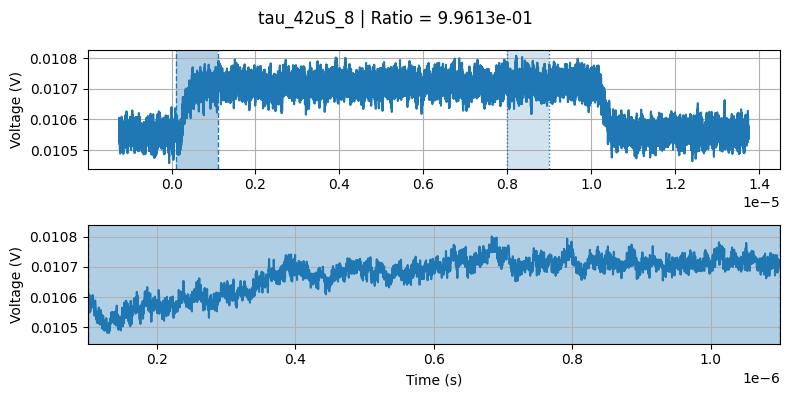

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


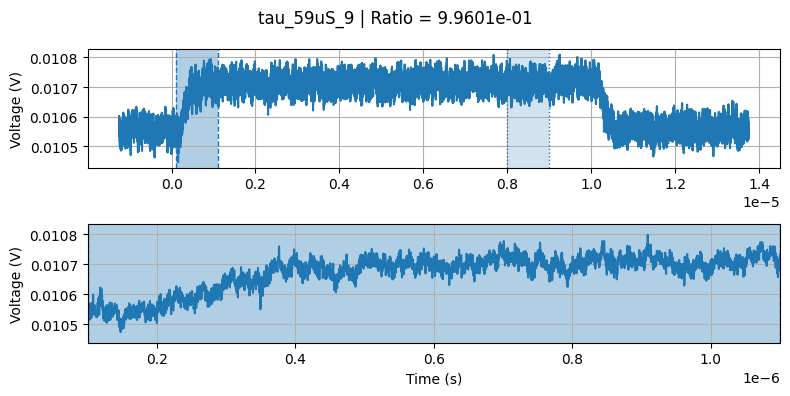

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


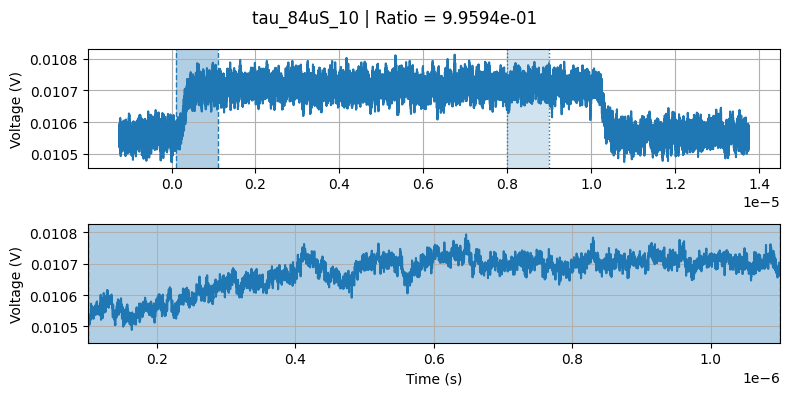

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


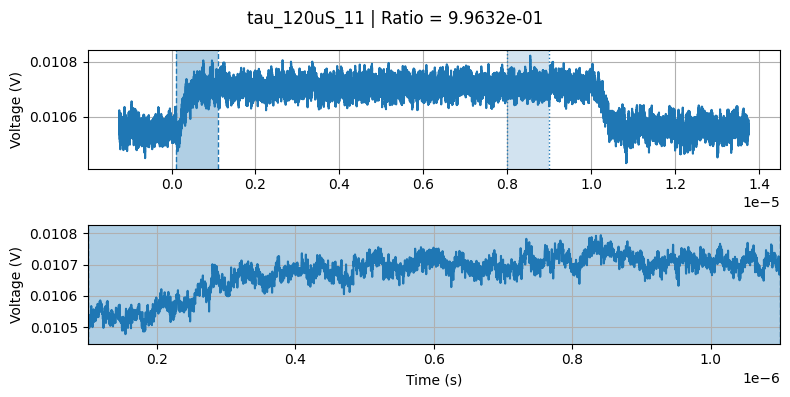

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


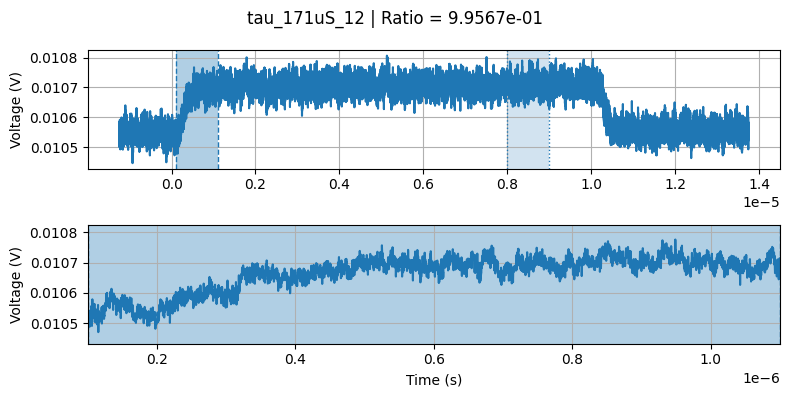

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


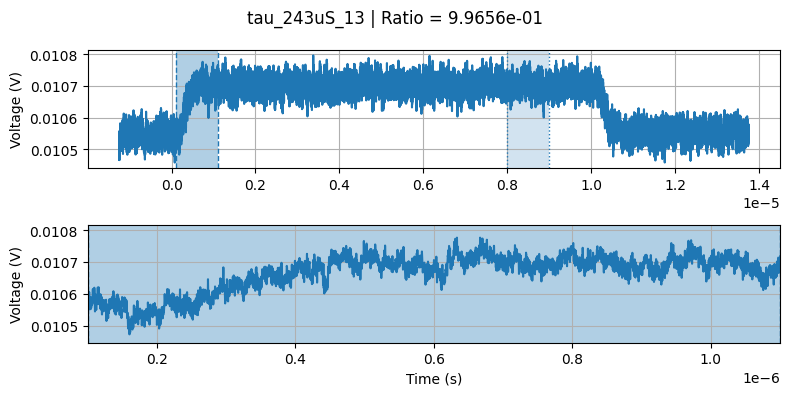

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


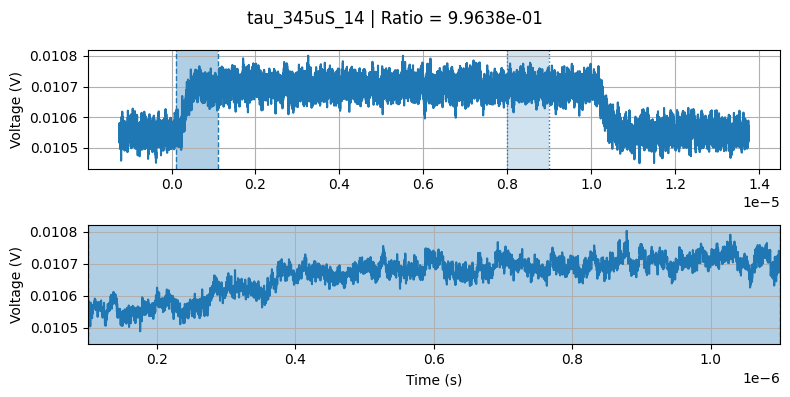

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


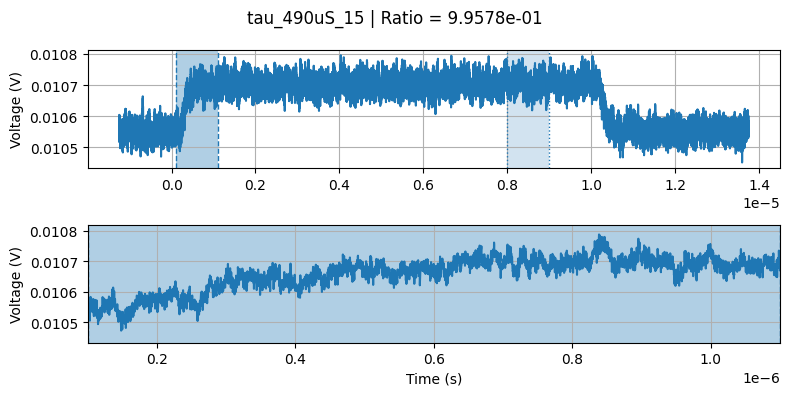

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


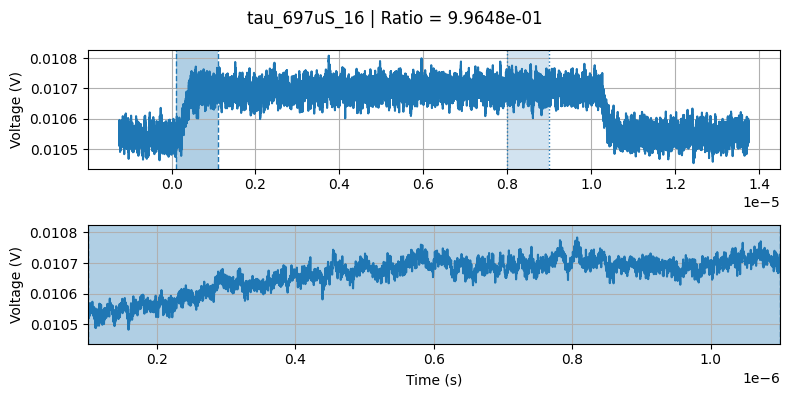

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


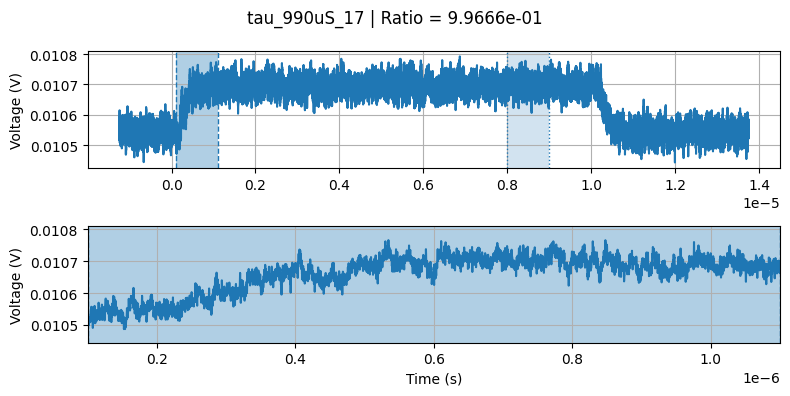

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


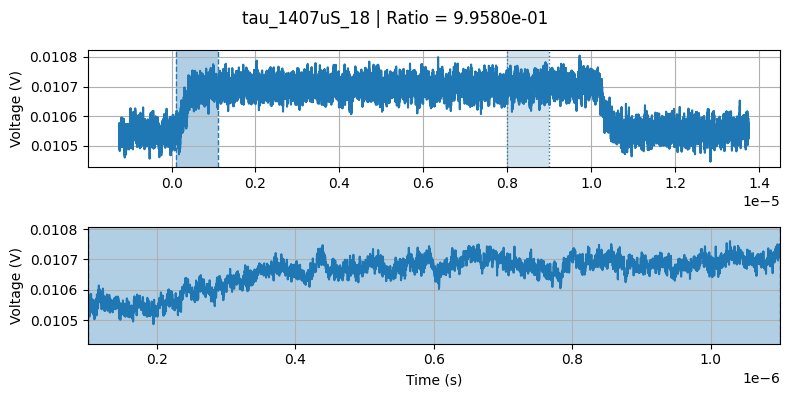

C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
C:\Users\QuDev\AppData\Local\Temp\ipykernel_36212\885905997.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])


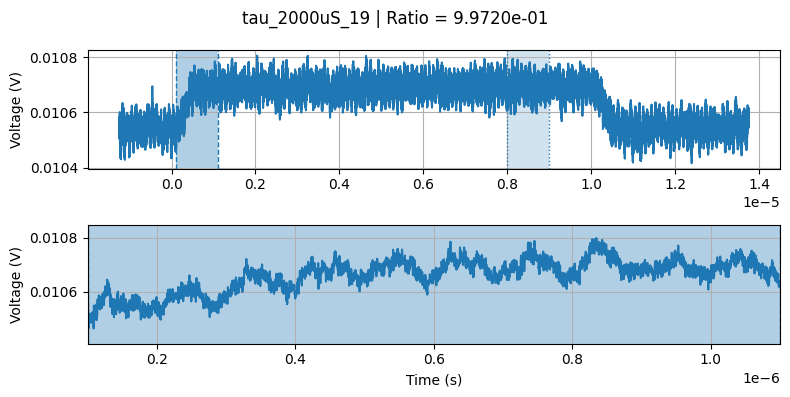

Saved to w1000ns_s100ns.pdf


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def extract_tau(folder_name):
    return int(folder_name.split('_')[1].replace('uS', ''))


# --- PARAMETERS (MATCH CALCULATION!) ---
polarize_pulse_width = 10e-6
readout_window = 1000e-9

read_start = 100e-9                     # reading window starts at 1 microsecond
read_end   = read_start + readout_window  # reading window ends at 1.2 microseconds
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window


# --- GET FOLDERS ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)
folders = sorted(folders, key=extract_tau)


file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:

        # Load data
        data_read = pd.read_csv(f"{tau}/averaged_waveform_read.csv")
        data_pol  = pd.read_csv(f"{tau}/averaged_waveform_pol.csv")

        data_read.columns = ["Time", "Voltage","Std"]
        data_pol.columns  = ["Time", "Voltage","Std"]

        time_read = data_read["Time"]
        voltage_read = data_read["Voltage"]

        time_pol = data_pol["Time"]
        voltage_pol = data_pol["Voltage"]

        # --- COMPUTE SIGNAL (for display) ---
        read_mask = (time_read >= read_start) & (time_read < read_end)
        ref_mask  = (time_pol >= t1) & (time_pol < t2)

        reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
        reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])

        signal = reading_int / reference_int if reference_int != 0 else np.nan

        # --- PLOTTING ---
        fig, axs = plt.subplots(2, 1, figsize=(8, 4))
        fig.suptitle(f"{tau} | Ratio = {signal:.4e}")

        # --- POLARIZING ---
        axs[0].plot(time_pol, voltage_pol)
        axs[0].grid(True)

        # --- READING ---
        axs[1].plot(time_read, voltage_read)
        axs[1].set_xlim(read_start, read_end)   # zoom into reading window
        axs[1].grid(True)

        # --- WINDOW MARKING ---
        for ax in axs:
            # Reading window
            ax.axvspan(read_start, read_end, alpha=0.35)

            # Reference window
            ax.axvspan(t1, t2, alpha=0.2)

            # Boundary lines
            ax.axvline(read_start, linestyle='--', linewidth=1)
            ax.axvline(read_end,   linestyle='--', linewidth=1)
            ax.axvline(t1, linestyle=':', linewidth=1)
            ax.axvline(t2, linestyle=':', linewidth=1)

        # --- LABELS ---
        axs[1].set_xlabel("Time (s)")
        axs[0].set_ylabel("Voltage (V)")
        axs[1].set_ylabel("Voltage (V)")

        # Annotations
        ymax_read = max(voltage_read[read_mask]) if read_mask.any() else max(voltage_read)
        # axs[1].text(read_start + readout_window * 0.1, ymax_read * 0.9, "Read", fontsize=8)

        ymax_pol = max(voltage_pol)
        # axs[0].text(t1, ymax_pol * 0.8, "Ref", fontsize=8)

        # Layout
        plt.tight_layout()
        plt.show()
        # Layout
        # plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
print(f"Saved to {file_name}.pdf")

# !!!

## 1

In [ ]:
import numpy as np
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 200e-9

    edge = 15e-9
    t0 = readout_window
    t1 = polarize_pulse_width*0.85
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= 0) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio:.4f}")

print(ratio_list)

import pandas as pd

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list
})

file_name = input("enter file name for the results: ")
# Save to Excel
df_result.to_excel(f"{file_name}_1.xlsx", index=False)

print(f"Saved to {file_name}_1.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9841
 3.247553478377444 | 0.9838
 5.273301797460717 | 0.9845
 8.562664797438789 | 0.9840
 13.903855923551212 | 0.9852
 22.57675783369378 | 0.9841
 36.65961421664872 | 0.9853
 59.527028832626364 | 0.9848
 96.65860477143505 | 0.9849
 156.95199407029216 | 0.9851
 254.85499714062672 | 0.9849
 413.82761622295806 | 0.9850
 671.9636572567563 | 0.9847
 1091.118956233703 | 0.9845
 1771.733580820165 | 0.9847
 2876.8997765753265 | 0.9844
 4671.442938180243 | 0.9845
 7585.3803814644925 | 0.9844
 12316.96422132051 | 0.9849
 20000.0 | 0.9843
[0.9841150076035711, 0.9838014958942773, 0.9844772381479777, 0.9840254609275061, 0.9851721949186102, 0.9840558292916043, 0.9852889613137357, 0.9847537329125217, 0.9848666478038949, 0.985060022834849, 0.9848848465560223, 0.9849921258294715, 0.9846582655436008, 0.9845274057685192, 0.9847132153259688, 0.9844066433982057, 0.9844814785578394, 0.9844353260257465, 0.984866333477223, 0.9843150391249726]
Saved to t1_results3.xlsx


## 2

In [ ]:
import numpy as np
import os 
import pandas as pd
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []
read_list = []
pol_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 200e-9

    edge = 15e-9
    t0 = readout_window
    t1 = polarize_pulse_width*0.5
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= 0) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int/reference_int
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio}")

print(ratio_list)

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list,
    "Reading" : read_list,
    "Reference" : pol_list
})

# Save to Excel
file_name = int(input("enter file number: "))
df_result.to_excel(f"t1_results{file_name}_2.xlsx", index=False)

print(f"Saved to t1_results{file_name}_2.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9843825489886115
 3.247553478377444 | 0.9847506463484834
 5.273301797460717 | 0.9842430038329415
 8.562664797438789 | 0.9845679558084063
 13.903855923551212 | 0.9860340229273049
 22.57675783369378 | 0.9848226773156764
 36.65961421664872 | 0.9859852242547511
 59.527028832626364 | 0.9849043721981042
 96.65860477143505 | 0.9855513028130098
 156.95199407029216 | 0.985868438980213
 254.85499714062672 | 0.9850197119031114
 413.82761622295806 | 0.9841252189381443
 671.9636572567563 | 0.9853113466450958
 1091.118956233703 | 0.9846166362423521
 1771.733580820165 | 0.9849736994241777
 2876.8997765753265 | 0.9850202562126704
 4671.442938180243 | 0.98504791574562
 7585.3803814644925 | 0.9848208710723637
 12316.96422132051 | 0.9852747203350644
 20000.0 | 0.9855974849154019
[0.9843825489886115, 0.9847506463484834, 0.9842430038329415, 0.9845679558084063, 0.9860340229273049, 0.9848226773156764, 0.9859852242547511, 0.9849043721981042, 0.9855513028130098, 0.98586843898021

## 3

In [35]:
import pandas as pd

df = pd.read_csv("tau_2us/averaged_waveform_pol.csv")

df.head()

,Time (s),Voltage (V),Std (V)
0,-0.000001,0.010568,0.000172
1,-0.000001,0.010567,0.000171
2,-0.000001,0.010573,0.000169
3,-0.000001,0.010578,0.000172
4,-0.000001,0.010568,0.000176


In [8]:
import numpy as np
import os 
import pandas as pd
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 40
num_waveform = 1000
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []
read_list = []
pol_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders[0:n]):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage","Std"]
    df_pol.columns = ["Time","Voltage","Std"]

    polarize_pulse_width = 10e-6
    
    readout_window = 2000e-9

    read_start = 300e-9
    t0 = read_start + readout_window
    t1 = polarize_pulse_width*0.8
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= read_start) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapezoid(reading["Voltage"], reading["Time"])
    reference_int = np.trapezoid(reference["Voltage"], reference["Time"])

    ratio = reading_int/reference_int
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio}")

# print(ratio_list)
# TROUBLESHOOTING
# print(f"{len(ratio_list)} | {len(read_list)} | {len(pol_list)}")
# print(len(tau))

# # Create DataFrame
# df_result = pd.DataFrame({
#     "Tau (us)": tau,
#     "Ratio": ratio_list,
#     "Reading" : read_list,
#     "Reference" : pol_list
# })

# # Save to Excel
# file_name = input("enter the file name: t1_01-04_..._no-std")
# df_result.to_excel(f"t1_01-04_{file_name}_no-std.xlsx", index=False)

# print(f"Saved to t1_01-04_{file_name}_no-std.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9994373662934568
 2.532760346934807 | 0.9994389539274735
 3.2074374875026606 | 0.9997410490084521
 4.061835241809472 | 0.999601641140257
 5.1438276181186895 | 0.9995050499375846
 6.514041311319567 | 0.9995085977532258
 8.249252765802705 | 0.9991357979548684
 10.446690148533683 | 0.9993758211558035
 13.2294812824603 | 0.9994796636539741
 16.753552801365835 | 0.9991676151210681
 21.21636710278897 | 0.9992525062608706
 26.867986651978004 | 0.9990259661293899
 34.025085597051785 | 0.9990581132145372
 43.08869380063767 | 0.9991534331345249
 54.56666752973537 | 0.9991409063583856
 69.10214589184437 | 0.9994592051096723
 87.50958750148371 | 0.9993404813121491
 110.82040660018986 | 0.9995102958778598
 140.34076573407646 | 0.9990235764309778
 177.72476325486798 | 0.9992208418741463
 225.06711652015295 | 0.9992146645363003
 285.0205340605996 | 0.9988326480219192
 360.9443533654341 | 0.9991745855105453
 457.0927728269982 | 0.9990675394859136
 578.8532249433505 | 0.

## 4

In [38]:
import numpy as np
import os 
import pandas as pd

# --- FUNCTIONS ---
def list_folder_names_os(directory_path):
    return [
        name for name in os.listdir(directory_path) 
        if os.path.isdir(os.path.join(directory_path, name))
    ]

# --- GET FOLDERS ---
directory_to_scan = '.'
tau_folders = sorted(
    list_folder_names_os(directory_to_scan),
    key=lambda x: int(x.split('_')[1].replace('uS', ''))
)

# --- PARAMETERS ---
tau_minimum = 2
tau_maximum = 20000
n = 40
tau = np.geomspace(tau_minimum, tau_maximum, n)

# --- WINDOWS ---
polarize_pulse_width = 10e-6
readout_window = 1000e-9
read_start = 300e-9
t0 = read_start + readout_window
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window

# --- STORAGE ---
ratio_list = []
read_list = []
pol_list = []

read_std_list = []
pol_std_list = []
ratio_err_list = []

print("Dark time (us) | Ratio")

# --- LOOP ---
for val_t, folder in enumerate(tau_folders):

    # --- LOAD DATA (WITH STD) ---
    df_pol = pd.read_csv(f"{folder}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{folder}/averaged_waveform_read.csv")

    df_read.columns = ["Time", "Voltage", "Std"]
    df_pol.columns  = ["Time", "Voltage", "Std"]

    reading = df_read[(df_read["Time"] >= read_start) & (df_read["Time"] < t0)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] < t2)]

    # --- INTEGRATION ---
    reading_int = np.trapezoid(reading["Voltage"], reading["Time"])
    reference_int = np.trapezoid(reference["Voltage"], reference["Time"])

    # --- STD PROPAGATION ---
    dt_read = np.mean(np.diff(reading["Time"]))
    dt_ref  = np.mean(np.diff(reference["Time"]))

    reading_std = np.sqrt(np.sum((reading["Std"] * dt_read)**2))
    reference_std = np.sqrt(np.sum((reference["Std"] * dt_ref)**2))

    # --- RATIO ---
    ratio = reading_int / reference_int

    # --- ERROR PROPAGATION ---
    ratio_err = ratio * np.sqrt(
        (reading_std / reading_int)**2 +
        (reference_std / reference_int)**2
    )

    # --- STORE ---
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)

    read_std_list.append(reading_std)
    pol_std_list.append(reference_std)
    ratio_err_list.append(ratio_err)

    print(f"{tau[val_t]} | {ratio} | {ratio_err}")

# --- SAVE ---
df_result = pd.DataFrame({
    "Tau (us)": tau,  # KEEP geomspace
    "Ratio": ratio_list,
    "Ratio Error": ratio_err_list,
    "Reading": read_list,
    "Reading STD": read_std_list,
    "Reference": pol_list,
    "Reference STD": pol_std_list
})

file_name = input("enter the file name: t1_06-04_..._final")
df_result.to_excel(f"t1_06-04_{file_name}_final.xlsx", index=False)

print(f"Saved to t1_06-04_{file_name}_final.xlsx")

Dark time (us) | Ratio
2.0 | 0.9987860731288632 | 0.00031159845166732307
2.532760346934807 | 0.9988144676571893 | 0.00031342020942668424
3.2074374875026606 | 0.9990612119277954 | 0.00031338851109046737
4.061835241809472 | 0.9991158420347258 | 0.00031329449787950145
5.1438276181186895 | 0.9988731626848187 | 0.0003128963699777037
6.514041311319567 | 0.9989733854163039 | 0.0003133648116111734
8.249252765802705 | 0.9985161131184951 | 0.000313005139524444
10.446690148533683 | 0.9987900534625734 | 0.0003131100475346917
13.2294812824603 | 0.9988871372963352 | 0.0003134856861338028
16.753552801365835 | 0.9984600021025477 | 0.00031335953101666996
21.21636710278897 | 0.9985499765997363 | 0.0003134417320254201
26.867986651978004 | 0.9984796038998195 | 0.00031491660793467574
34.025085597051785 | 0.9984710916298017 | 0.0003146567508390981
43.08869380063767 | 0.9985380072845434 | 0.0003145149759838442
54.56666752973537 | 0.9985155783065959 | 0.0003146097635471885
69.10214589184437 | 0.99895174883539

# Curve fit

## Single exponential

Initial guesses → I0: 1.0627e-08, A: 0.0004, T1: 110.55 µs
Signal = 1.0627e-08 * (1 + 0.0007 * exp(-t / 4.45 µs))
T1 = 4.45 ± 0.20 µs  →  0.0044 ± 0.0002 ms
R² = 0.882715


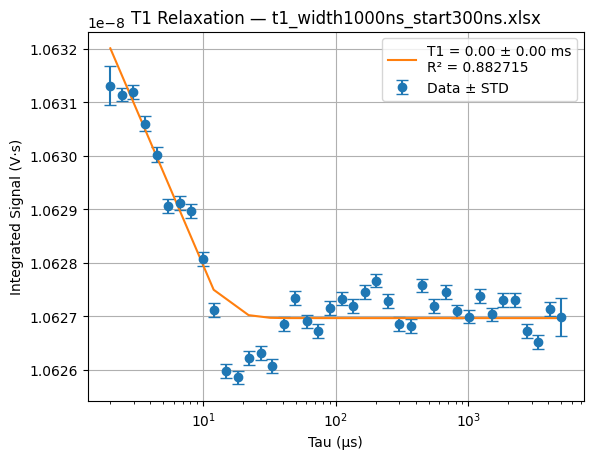

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
file_name = "t1_width1000ns_start300ns.xlsx"
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
signal = df["Signal"].values
signal_err = df["Signal Error"].values

# Work in microseconds to avoid scaling issues
t = tau_us  # keep in µs

# --- MODEL (t in µs, T1 in µs) ---
def exp_decay(t, I0, A, T1):
    return I0 * (1 + A * np.exp(-t / T1))

# --- INITIAL GUESSES ---
I0_guess = signal[-1]                        # asymptote ~ last point
A_guess = (signal[0] / signal[-1]) - 1      # approximate fractional amplitude
T1_guess = tau_us[len(tau_us) // 2]         # midpoint tau as T1 estimate

p0 = [I0_guess, A_guess, T1_guess]
print(f"Initial guesses → I0: {I0_guess:.4e}, A: {A_guess:.4f}, T1: {T1_guess:.2f} µs")

# --- BOUNDS: T1 must be positive, A can be negative for inversion recovery ---
bounds = ([-np.inf, -np.inf, 1e-3], [np.inf, np.inf, np.inf])

params, cov = curve_fit(
    exp_decay,
    t,
    signal,
    p0=p0,
    sigma=signal_err,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

I0, A, T1 = params
T1_err = np.sqrt(np.diag(cov))[2]

# --- R² ---
y_fit_data = exp_decay(t, *params)
ss_res = np.sum((signal - y_fit_data) ** 2)
ss_tot = np.sum((signal - np.mean(signal)) ** 2)
R2 = 1 - (ss_res / ss_tot)

# --- GENERATE FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)

print(f"Signal = {I0:.4e} * (1 + {A:.4f} * exp(-t / {T1:.2f} µs))")
print(f"T1 = {T1:.2f} ± {T1_err:.2f} µs  →  {T1/1e3:.4f} ± {T1_err/1e3:.4f} ms")
print(f"R² = {R2:.6f}")

# --- PLOT ---
plt.figure()
plt.errorbar(tau_us, signal, yerr=signal_err, fmt='o', capsize=4, label="Data ± STD")
plt.plot(
    t_fit,
    y_fit,
    label=f"T1 = {T1/1e3:.2f} ± {T1_err/1e3:.2f} ms\nR² = {R2:.6f}"
)
# plt.xlim(0,1000)
# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Integrated Signal (V·s)")
plt.title(f"T1 Relaxation — {file_name}")
plt.grid(True)
plt.legend()
plt.show()

## 1 Rep

Initial guesses → I0: 1.0620e-08, A: 0.0010, T1: 110.55 µs
Signal = 1.0620e-08 * (1 + 0.0010 * exp(-t / 110.55 µs))
T1 = 110.55 ± 12496400760635.76 µs  →  0.1106 ± 12496400760.6358 ms
R² = -0.098151


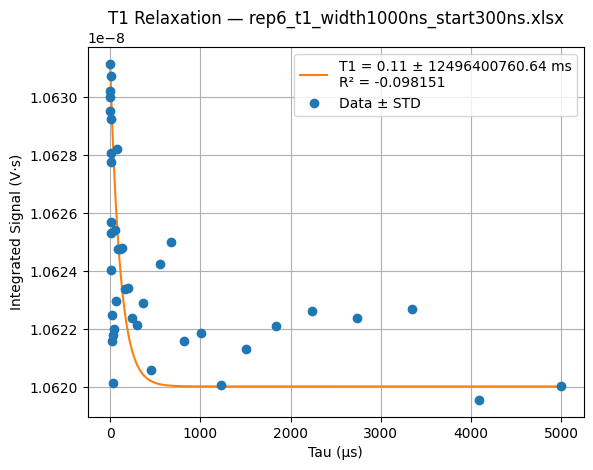

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
rep = int(input("no. of rep: "))
file_name = f"rep{rep}_t1_width1000ns_start300ns.xlsx"
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
signal = df["Signal"].values
# signal_err = df["Signal Error"].values

# Work in microseconds to avoid scaling issues
t = tau_us  # keep in µs

# --- MODEL (t in µs, T1 in µs) ---
def exp_decay(t, I0, A, T1):
    return I0 * (1 + A * np.exp(-t / T1))

# --- INITIAL GUESSES ---
I0_guess = signal[-1]                        # asymptote ~ last point
A_guess = (signal[0] / signal[-1]) - 1      # approximate fractional amplitude
T1_guess = tau_us[len(tau_us) // 2]         # midpoint tau as T1 estimate

p0 = [I0_guess, A_guess, T1_guess]
print(f"Initial guesses → I0: {I0_guess:.4e}, A: {A_guess:.4f}, T1: {T1_guess:.2f} µs")

# --- BOUNDS: T1 must be positive, A can be negative for inversion recovery ---
bounds = ([-np.inf, -np.inf, 1e-3], [np.inf, np.inf, np.inf])

params, cov = curve_fit(
    exp_decay,
    t,
    signal,
    p0=p0,
    # sigma=signal_err,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

I0, A, T1 = params
T1_err = np.sqrt(np.diag(cov))[2]

# --- R² ---
y_fit_data = exp_decay(t, *params)
ss_res = np.sum((signal - y_fit_data) ** 2)
ss_tot = np.sum((signal - np.mean(signal)) ** 2)
R2 = 1 - (ss_res / ss_tot)

# --- GENERATE FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)

print(f"Signal = {I0:.4e} * (1 + {A:.4f} * exp(-t / {T1:.2f} µs))")
print(f"T1 = {T1:.2f} ± {T1_err:.2f} µs  →  {T1/1e3:.4f} ± {T1_err/1e3:.4f} ms")
print(f"R² = {R2:.6f}")

# --- PLOT ---
plt.figure()
plt.errorbar(tau_us, signal, fmt='o', capsize=4, label="Data ± STD")
plt.plot(
    t_fit,
    y_fit,
    label=f"T1 = {T1/1e3:.2f} ± {T1_err/1e3:.2f} ms\nR² = {R2:.6f}"
)
# plt.xlim(0,1000)
# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Integrated Signal (V·s)")
plt.title(f"T1 Relaxation — {file_name}")
plt.grid(True)
plt.legend()
plt.show()

## Bi-exponential

Initial guesses:
  I0      : 1.0627e-08
  A_short : 0.0002
  T1_short: 14.87 µs
  A_long  : 0.0002
  T1_long : 821.92 µs

Fit Results:
  I0       = 1.0627e-08 ± 2.8095e-14
  A_short  = 0.0637 ± 0.0038
  T1_short = 12.73 ± 0.48 µs  →  0.0127 ± 0.0005 ms
  A_long   = -0.0631 ± 0.0038
  T1_long  = 12.86 ± 0.48 µs  →  0.0129 ± 0.0005 ms
  R²       = 0.946728


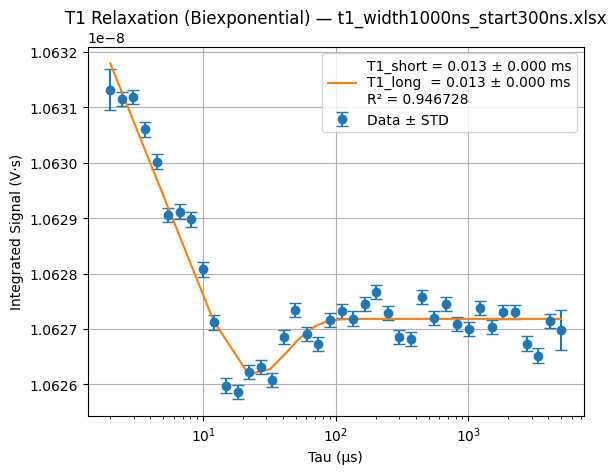

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
file_name = "t1_width1000ns_start300ns.xlsx"
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
signal = df["Signal"].values
signal_err = df["Signal Error"].values

t = tau_us  # keep in µs

# --- MODEL ---
def biexp_decay(t, I0, A_short, T1_short, A_long, T1_long):
    return I0 * (1 + A_short * np.exp(-t / T1_short) + A_long * np.exp(-t / T1_long))

# --- INITIAL GUESSES ---
I0_guess     = signal[-1]
A_short_guess = 0.5 * ((signal[0] / signal[-1]) - 1)   # split amplitude equally
A_long_guess  = 0.5 * ((signal[0] / signal[-1]) - 1)
T1_short_guess = tau_us[len(tau_us) // 4]               # earlier quarter as short T1
T1_long_guess  = tau_us[3 * len(tau_us) // 4]           # later quarter as long T1

p0 = [I0_guess, A_short_guess, T1_short_guess, A_long_guess, T1_long_guess]
print(f"Initial guesses:")
print(f"  I0      : {I0_guess:.4e}")
print(f"  A_short : {A_short_guess:.4f}")
print(f"  T1_short: {T1_short_guess:.2f} µs")
print(f"  A_long  : {A_long_guess:.4f}")
print(f"  T1_long : {T1_long_guess:.2f} µs")

# --- BOUNDS ---
# T1_short and T1_long must be positive; A can be negative
bounds = (
    [-np.inf, -np.inf, 1e-3,          -np.inf, 1e-3         ],  # lower
    [ np.inf,  np.inf, np.inf,          np.inf, np.inf       ]   # upper
)

params, cov = curve_fit(
    biexp_decay,
    t,
    signal,
    p0=p0,
    sigma=signal_err,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=20000
)

I0, A_short, T1_short, A_long, T1_long = params
perr = np.sqrt(np.diag(cov))
I0_err, A_short_err, T1_short_err, A_long_err, T1_long_err = perr

# --- enforce T1_short < T1_long (swap if needed) ---
if T1_short > T1_long:
    T1_short, T1_long = T1_long, T1_short
    A_short, A_long   = A_long, A_short
    T1_short_err, T1_long_err = T1_long_err, T1_short_err
    A_short_err, A_long_err   = A_long_err, A_short_err

# --- R² ---
y_fit_data = biexp_decay(t, *params)
ss_res = np.sum((signal - y_fit_data) ** 2)
ss_tot = np.sum((signal - np.mean(signal)) ** 2)
R2 = 1 - (ss_res / ss_tot)

# --- GENERATE FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = biexp_decay(t_fit, I0, A_short, T1_short, A_long, T1_long)

# --- PRINT RESULTS ---
print(f"\nFit Results:")
print(f"  I0       = {I0:.4e} ± {I0_err:.4e}")
print(f"  A_short  = {A_short:.4f} ± {A_short_err:.4f}")
print(f"  T1_short = {T1_short:.2f} ± {T1_short_err:.2f} µs  →  {T1_short/1e3:.4f} ± {T1_short_err/1e3:.4f} ms")
print(f"  A_long   = {A_long:.4f} ± {A_long_err:.4f}")
print(f"  T1_long  = {T1_long:.2f} ± {T1_long_err:.2f} µs  →  {T1_long/1e3:.4f} ± {T1_long_err/1e3:.4f} ms")
print(f"  R²       = {R2:.6f}")

# --- PLOT ---
plt.figure()
plt.errorbar(tau_us, signal, yerr=signal_err, fmt='o', capsize=4, label="Data ± STD")
plt.plot(
    t_fit, y_fit,
    label=(
        f"T1_short = {T1_short/1e3:.3f} ± {T1_short_err/1e3:.3f} ms\n"
        f"T1_long  = {T1_long/1e3:.3f} ± {T1_long_err/1e3:.3f} ms\n"
        f"R² = {R2:.6f}"
    )
)
# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Integrated Signal (V·s)")
plt.title(f"T1 Relaxation (Biexponential) — {file_name}")
plt.grid(True)
plt.legend()
plt.show()


Tau (us) | Ratio | STD (Ratio Error)
    2.53 | 9.8884e-01 | 4.56e-04
    3.60 | 9.8868e-01 | 4.53e-04
    5.11 | 9.8958e-01 | 4.53e-04
    7.26 | 9.8911e-01 | 4.62e-04
   10.32 | 9.9011e-01 | 4.53e-04
   14.66 | 9.8857e-01 | 4.49e-04
   20.82 | 9.8995e-01 | 4.54e-04
   29.58 | 9.9090e-01 | 4.61e-04
   42.03 | 9.9011e-01 | 4.62e-04
   59.71 | 9.9040e-01 | 4.54e-04
   84.83 | 9.9040e-01 | 4.61e-04
  120.52 | 9.9022e-01 | 4.55e-04
  171.22 | 9.9030e-01 | 4.62e-04
  243.25 | 9.9082e-01 | 4.53e-04
  345.58 | 9.9092e-01 | 4.57e-04
  490.96 | 9.8968e-01 | 4.54e-04
  697.49 | 9.9067e-01 | 4.60e-04
  990.92 | 9.9037e-01 | 4.52e-04
 1407.78 | 9.9106e-01 | 4.57e-04
 2000.00 | 9.9155e-01 | 4.54e-04
Ratio = 0.9906 + -0.0019exp(-t)/2.0628240927815953e-05


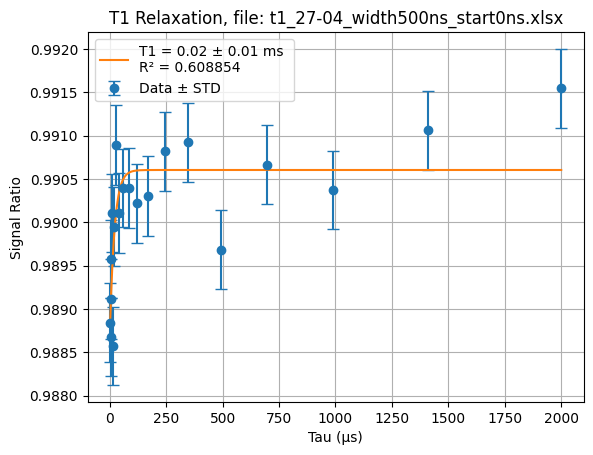

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
file_name = "t1_27-04_width500ns_start0ns.xlsx"
df = pd.read_excel(file_name)  # change file name

tau_us = df["Tau (us)"].values
ratio = df["Ratio"].values
ratio_err = df["Ratio Error"].values

t = tau_us * 1e-6


# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- WEIGHTED FIT (IMPORTANT) ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]

params, cov = curve_fit(
    exp_decay,
    t,
    ratio,
    p0=p0,
    sigma=ratio_err,
    absolute_sigma=True
)

I0, A, T1 = params
T1_err = np.sqrt(np.diag(cov))[2]

# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)

# --- PRINT EACH DATA POINT WITH STD ---
print("\nTau (us) | Ratio | STD (Ratio Error)")
for tau_val, r, err in zip(tau_us, ratio, ratio_err):
    print(f"{tau_val:8.2f} | {r:8.4e} | {err:.2e}")


# --- GENERATE FIT ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)
print(f"Ratio = {I0:.4f} + {A:.4f}exp(-t)/{T1}")

# --- PLOT ---
plt.figure()

# Error bars (this IS the STD)
plt.errorbar(
    tau_us,
    ratio,
    yerr=ratio_err,
    fmt='o',
    capsize=4,
    label="Data ± STD"
)

# Fit curve
plt.plot(
    t_fit * 1e6,
    y_fit,
    label=f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms \nR² = {R2:.6f}"
)

# --- OPTIONAL: annotate each point ---
# for x, y, err in zip(tau_us, ratio, ratio_err):
#     plt.text(x, y, f"{err:.1e}", fontsize=7)

# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation, file: {file_name}")

# ZOOM IN
# plt.xlim(0, 100)

plt.grid(True)
plt.legend()

plt.show()


Tau (us) | Ratio | STD (Ratio Error)
    2.53 | 1.0686e-08 | 2.46e-12
    3.60 | 1.0685e-08 | 2.43e-12
    5.11 | 1.0681e-08 | 2.47e-12
    7.26 | 1.0678e-08 | 2.49e-12
   10.32 | 1.0674e-08 | 2.44e-12
   14.66 | 1.0667e-08 | 2.44e-12
   20.82 | 1.0664e-08 | 2.45e-12
   29.58 | 1.0665e-08 | 2.49e-12
   42.03 | 1.0655e-08 | 2.48e-12
   59.71 | 1.0653e-08 | 2.44e-12
   84.83 | 1.0653e-08 | 2.48e-12
  120.52 | 1.0654e-08 | 2.44e-12
  171.22 | 1.0647e-08 | 2.46e-12
  243.25 | 1.0648e-08 | 2.45e-12
  345.58 | 1.0646e-08 | 2.42e-12
  490.96 | 1.0641e-08 | 2.44e-12
  697.49 | 1.0644e-08 | 2.46e-12
  990.92 | 1.0642e-08 | 2.46e-12
 1407.78 | 1.0642e-08 | 2.48e-12
 2000.00 | 1.0643e-08 | 2.44e-12
Ratio = 0.0000 + 0.0000exp(-t)/3.308462256064232e-05


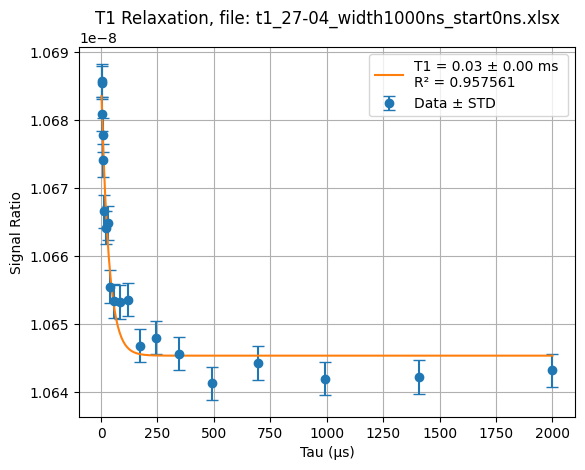

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
file_name = "t1_27-04_width1000ns_start0ns.xlsx"
df = pd.read_excel(file_name)  # change file name

tau_us = df["Tau (us)"].values
ratio = df["Reading"].values
ratio_err = df["Reading STD"].values

t = tau_us * 1e-6


# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- WEIGHTED FIT (IMPORTANT) ---
p0 = [min(ratio), max(ratio), 1e-3]

params, cov = curve_fit(
    exp_decay,
    t,
    ratio,
    p0=p0,
    sigma=ratio_err,
    absolute_sigma=True
)

I0, A, T1 = params
T1_err = np.sqrt(np.diag(cov))[2]

# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)

# --- PRINT EACH DATA POINT WITH STD ---
print("\nTau (us) | Ratio | STD (Ratio Error)")
for tau_val, r, err in zip(tau_us, ratio, ratio_err):
    print(f"{tau_val:8.2f} | {r:8.4e} | {err:.2e}")


# --- GENERATE FIT ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)
print(f"Ratio = {I0:.4f} + {A:.4f}exp(-t)/{T1}")

# --- PLOT ---
plt.figure()

# Error bars (this IS the STD)
plt.errorbar(
    tau_us,
    ratio,
    yerr=ratio_err,
    fmt='o',
    capsize=4,
    label="Data ± STD"
)

# Fit curve
plt.plot(
    t_fit * 1e6,
    y_fit,
    label=f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms \nR² = {R2:.6f}"
)

# --- OPTIONAL: annotate each point ---
# for x, y, err in zip(tau_us, ratio, ratio_err):
#     plt.text(x, y, f"{err:.1e}", fontsize=7)

# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation, file: {file_name}")

# ZOOM IN
# plt.xlim(0, 100)

plt.grid(True)
plt.legend()

plt.show()

# Comparison

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

list_readout_window = [1000e-9]
list_read_start = [300e-9]

print("Window width (us) | Read start (us) | T1 (ms) | T1 err | R²")

# --- PARAMETERS ---
tau_minimum = 2
tau_maximum = 5000
n = 40
tau = np.geomspace(tau_minimum, tau_maximum, n)

# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 * (1 + A * np.exp(-t / T1))

# --- LOAD AVERAGED FILES ---
input_dir = input("Input the directory path: ")
directory_to_scan = input_dir.strip().strip('"')

averaged_dir = os.path.join(directory_to_scan, "averaged_results")
averaged_files = sorted(
    [f for f in os.listdir(averaged_dir) if f.startswith("averaged_tau_")],
    key=lambda x: int(x.split("_")[2].replace("uS", ""))  # sort by tau value
)

for width in list_readout_window:
    for start in list_read_start:
        # --- WINDOWS ---
        readout_window = width
        read_start = start
        t0 = read_start + readout_window

        # --- STORAGE ---
        signal_list = []
        signal_std_list = []

        # --- LOOP OVER TAU ---
        for fname in averaged_files:
            df = pd.read_csv(os.path.join(averaged_dir, fname))
            df.columns = ["Time", "Voltage", "Std"]

            # --- WINDOW ---
            reading = df[(df["Time"] >= read_start) & (df["Time"] < t0)]

            # --- INTEGRATION ---
            signal_int = np.trapezoid(reading["Voltage"], reading["Time"])

            # --- STD PROPAGATION ---
            dt = np.mean(np.diff(reading["Time"]))
            signal_err = np.sqrt(np.sum((reading["Std"] * dt) ** 2))

            # --- STORE ---
            signal_list.append(signal_int)
            signal_std_list.append(signal_err)

        # --- DATAFRAME ---
        df_result = pd.DataFrame({
            "Tau (us)": tau,
            "Signal": signal_list,
            "Signal Error": signal_std_list,
        })

        tau_us = df_result["Tau (us)"].values
        signal = df_result["Signal"].values
        signal_err = df_result["Signal Error"].values

        t = tau_us * 1e-6

        # --- WEIGHTED FIT ---
        p0 = [min(signal), 1.0, 1e-3]

        try:
            params, cov = curve_fit(
                exp_decay,
                t,
                signal,
                p0=p0,
                sigma=signal_err,
                absolute_sigma=True,
                bounds=([0, 0, 0], [np.inf, np.inf, np.inf])  # I0, A, T1 all positive
            )

            I0, A, T1 = params
            T1_err = np.sqrt(np.diag(cov))[2]

            # --- R² ---
            y_fit = exp_decay(t, *params)
            ss_res = np.sum((signal - y_fit) ** 2)
            ss_tot = np.sum((signal - np.mean(signal)) ** 2)
            R2 = 1 - (ss_res / ss_tot)

            print(f"{width*1e6:.1f} | {start*1e6:.1f} | {T1*1e3:.2f} | {T1_err*1e3:.2f} | {R2:.6f}")

            # --- SAVE EXCEL ---
            # df_result.to_excel(
            #     f"t1_width{width*1e9:.0f}ns_start{start*1e9:.0f}ns.xlsx",
            #     index=False
            # )
            df_result.to_excel(
                os.path.join(directory_to_scan, f"t1_width{width*1e9:.0f}ns_start{start*1e9:.0f}ns.xlsx"),
                index=False
            )

        except RuntimeError:
            print(f"{width*1e6:.1f} | {start*1e6:.1f} | FIT FAILED")

Window width (us) | Read start (us) | T1 (ms) | T1 err | R²
1.0 | 0.3 | 0.00 | 0.00 | 0.882717


## 1 rep

In [28]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# SETTINGS
# ============================================================
rep = int(input("insert no. of rep: "))

rep_dir = f"./rep_{rep}"   # folder for one repetition only

list_readout_window = [1000e-9]
list_read_start = [300e-9]

tau_minimum = 2       # µs
tau_maximum = 5000    # µs
n = 40
tau = np.geomspace(tau_minimum, tau_maximum, n)

print("Window width (us) | Read start (us) | T1 (ms) | T1 err (ms) | R²")


# ============================================================
# MODEL
# t and T1 are both in µs
# ============================================================

def exp_decay(t, I0, A, T1):
    return I0 * (1 + A * np.exp(-t / T1))


def calculate_r2(y_true, y_fit):
    ss_res = np.sum((y_true - y_fit) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan


# ============================================================
# LOAD FILES FROM ONE REPETITION FOLDER ONLY
# ============================================================

rep_files = sorted(
    [f for f in os.listdir(rep_dir) if f.startswith("tau_") and f.endswith(".csv")],
    key=lambda x: int(x.split("_")[1].replace("uS", "").replace(".csv", ""))
)

if len(rep_files) != len(tau):
    print(f"Warning: number of files = {len(rep_files)}, but tau points = {len(tau)}")


# ============================================================
# INTEGRATION + FITTING LOOP
# ============================================================

for width in list_readout_window:
    for start in list_read_start:

        readout_window = width
        read_start = start
        t0 = read_start + readout_window

        signal_list = []

        # ----------------------------------------------------
        # Integrate each tau file inside rep_0
        # ----------------------------------------------------
        for fname in rep_files:
            file_path = os.path.join(rep_dir, fname)

            df = pd.read_csv(file_path)

            # Adjust this depending on your raw CSV format
            if len(df.columns) == 2:
                df.columns = ["Time", "Voltage"]
            elif len(df.columns) == 3:
                df.columns = ["Time", "Voltage", "Std"]
            else:
                raise ValueError(f"Unexpected column number in {fname}: {len(df.columns)}")

            reading = df[
                (df["Time"] >= read_start) &
                (df["Time"] < t0)
            ]

            if reading.empty:
                signal_int = np.nan
            else:
                signal_int = np.trapezoid(reading["Voltage"], reading["Time"])

            signal_list.append(signal_int)

        # ----------------------------------------------------
        # Make dataframe
        # ----------------------------------------------------
        df_result = pd.DataFrame({
            "Tau (us)": tau[:len(signal_list)],
            "Signal": signal_list
        })

        df_result = df_result.dropna()

        tau_us = df_result["Tau (us)"].values
        signal = df_result["Signal"].values

        # Keep t in microseconds
        t = tau_us

        # ----------------------------------------------------
        # Curve fitting
        # ----------------------------------------------------
        try:
            I0_guess = signal[-1]
            A_guess = (signal[0] / signal[-1]) - 1
            T1_guess = tau_us[len(tau_us) // 2]

            p0 = [I0_guess, A_guess, T1_guess]

            bounds = (
                [-np.inf, -np.inf, 1e-3],
                [np.inf, np.inf, np.inf]
            )

            params, cov = curve_fit(
                exp_decay,
                t,
                signal,
                p0=p0,
                bounds=bounds,
                maxfev=10000
            )

            I0, A, T1 = params
            T1_err = np.sqrt(np.diag(cov))[2]

            y_fit_data = exp_decay(t, *params)
            R2 = calculate_r2(signal, y_fit_data)

            print(
                f"{width*1e6:.1f} | "
                f"{start*1e6:.1f} | "
                f"{T1/1e3:.4f} | "
                f"{T1_err/1e3:.4f} | "
                f"{R2:.6f}"
            )

            # ------------------------------------------------
            # Save integrated signal from this repetition
            # ------------------------------------------------
            output_name = f"rep{rep}_t1_width{width*1e9:.0f}ns_start{start*1e9:.0f}ns.xlsx"
            df_result.to_excel(output_name, index=False)

        except RuntimeError:
            print(f"{width*1e6:.1f} | {start*1e6:.1f} | FIT FAILED")

        except Exception as e:
            print(f"{width*1e6:.1f} | {start*1e6:.1f} | ERROR: {e}")

Window width (us) | Read start (us) | T1 (ms) | T1 err (ms) | R²
1.0 | 0.3 | 0.1106 | 0.0438 | -0.098151
